# ML-Based Patient Enrichment Pipeline

This notebook implements a workflow where **machine learning predictions are used to support patient enrichment** for clinical trial screening. The goal is to use a **patient-level ensemble predicted probability** to identify candidates for an **enriched cohort**.

## Notebook roadmap

This notebook is organized into two chapters:

1. **Threshold-based enrichment design and study planning**  
   Define a fixed enrichment threshold, summarize how that threshold changes subgroup composition, and estimate the sample size needed for the next study.

2. **Prospective enrichment workflow**  
   Demonstrate how the ensemble model is applied to patient-level data to determine which patients are selected for enrichment.

---

# Chapter 1. Threshold-based enrichment design and study planning
This chapter defines the enrichment rule using a fixed probability threshold and evaluates how that rule changes subgroup composition in the screened population.

The goal is to answer two questions:

1. **What does the threshold do?**  
   How many patients are selected, how enriched is the selected subgroup for ASD, and how many ASD and TD patients are captured or excluded?

2. **What does the threshold imply for the next study?**  
   Given the observed PPV and percent selected, how many selected patients are needed to validate the enrichment rule with acceptable precision, and how many patients would need to be screened to obtain them?

#### import the needed packages

In [1]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs

import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut
import ai_framework.validation as vld

import pandas as pd
import numpy as np


##### Load final results and selected features per model

In [2]:
# Load output
all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
final_features    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_features', compress=True)
bundle            = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


##### Pooled patient risk summary: **"all_trials"**
- all_trials:      ["model","variant","split","group"]

    Pools window-level predictions for a patient across ALL CV runs (trial × outer_fold).
    
    Interpretation: for each patient, pool *all* out-of-sample window-level predictions across all runs, then compute a single patient-level center + spread.

    Note: default assumes you did `StratifiedGroupkfold` hence "group" in all_trials. If not, use unit_col='idx' for `Stratifiedkfold`

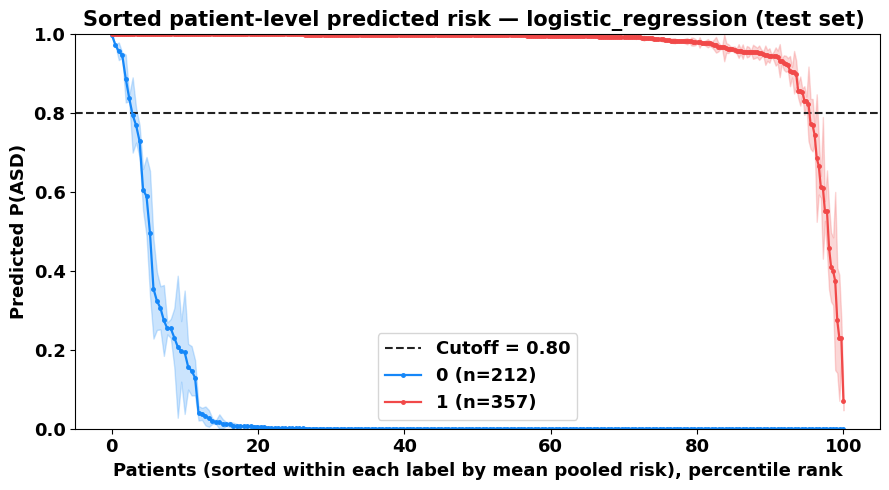

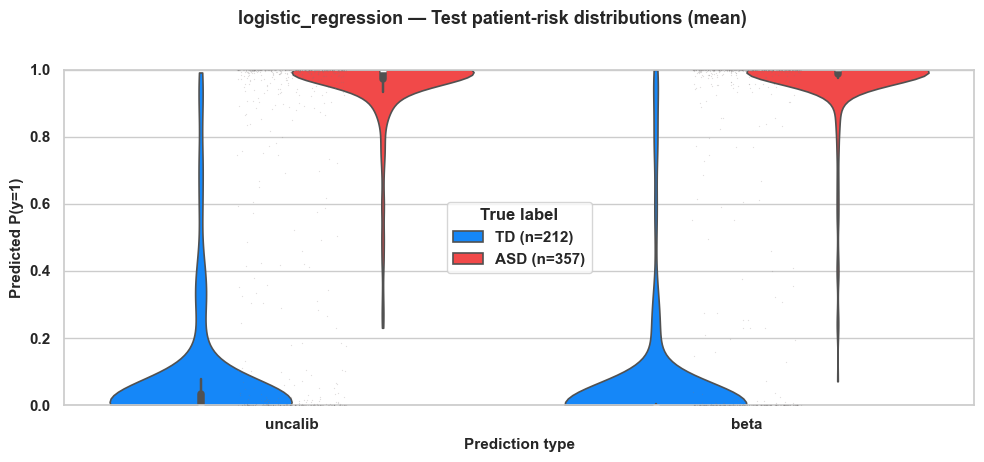

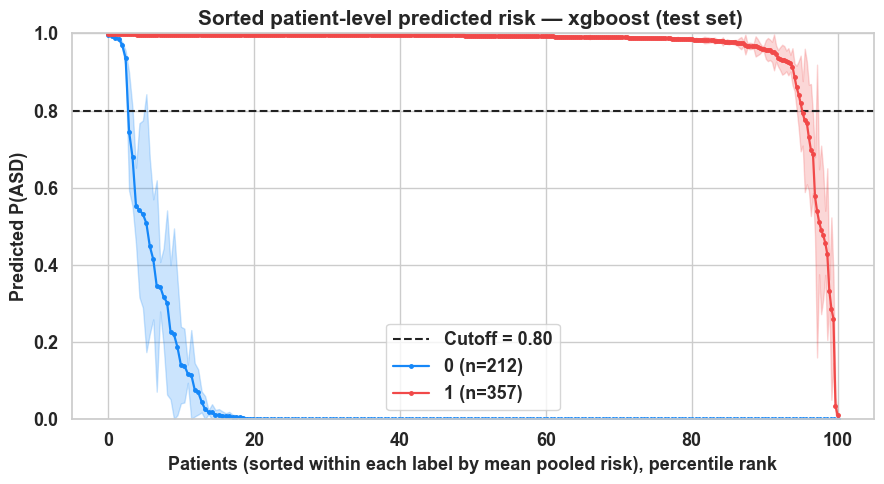

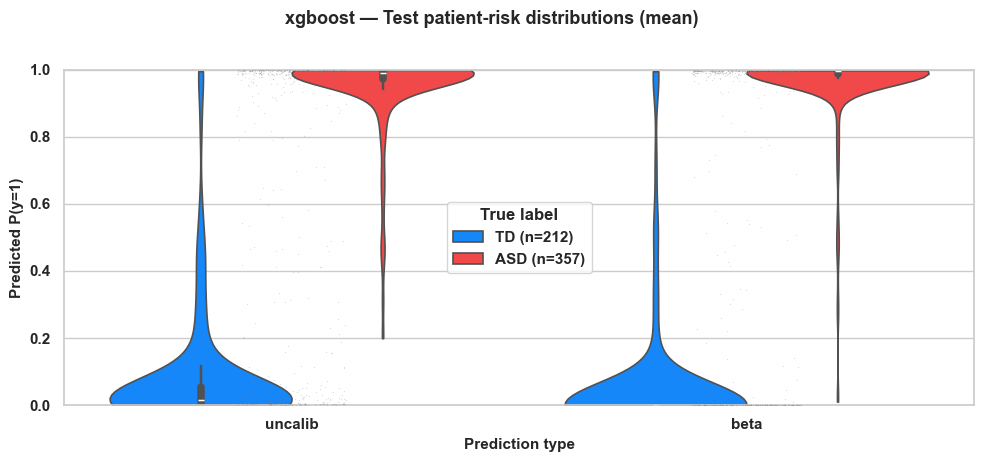

In [3]:

df_long = mtci.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    groups_all = None,
    group_id_to_key=None,
    include_uncalibrated=True,
    include_test=True,
    include_train_oof=False,   # keep off for now
    unit_col="idx"
)


df_pat = mtci.pooled_patient_risk_summary(
    df_long,
    grouping="all_trials", # per_trial_fold
    unit_col="idx",
    agg="mean",
    lower_q=0.0,
    upper_q=1.0,
    include_test=True,
    include_train_oof=False,
    truncate_decimals=4,
)



# Fixed enrichment threshold:
# patients with predicted probability >= 0.80 are treated as selected
threshold = 0.80

out_pat = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="logistic_regression",
    variants=[ "beta"],
    colors=["#1587F8", "#F14949"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)




_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="logistic_regression",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)":  "#1587F8", "1 (pos)": "#F14949"},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "TD", "1 (pos)": "ASD"},
)



out_pat_xgb = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="xgboost",
    variants=[ "beta"],
    colors=["#1587F8", "#F14949"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)


_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="xgboost",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)":  "#1587F8", "1 (pos)": "#F14949"},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "TD", "1 (pos)": "ASD"},
)





## Threshold-based enrichment analysis


This section applies the fixed enrichment threshold to patient-level predictions in order to define a selected subgroup.

The enrichment analysis is summarized at three levels:

1. **Pocket summary**  
   Describes the selected subgroup itself, including the number selected, PPV, contamination, and enrichment factor.

2. **Operating summary**  
   Describes what the threshold does in the full screened population, including sensitivity, specificity, NPV, percent selected, and screening burden.

3. **Planning summary**  
   Uses the observed PPV and percent selected to estimate how many selected patients are needed to validate the enrichment rule with a desired level of precision, and how many total patients would need to be screened to obtain them.


### Why this is useful (use case for clinical data)
Clinical data classification performance is often modest at the population level. This function supports the hypothesis that **data separability is heterogeneous**: there may exist subsets of individuals for whom clinical data provides stronger, more consistent discriminative signal. Identifying and quantifying these pockets enables **focused follow-up analyses** and motivates **enrichment strategies** for future studies (e.g., prioritizing Eseparable individuals for deeper phenotyping or prospective validation).


In [4]:
# Fixed enrichment threshold:
# patients with predicted probability >= 0.80 are treated as selected
threshold = 0.80

# Run the full enrichment pipeline for each model in df_pat.
# This wrapper does three things for every model:
#   1. computes the pocket summary for the selected subgroup,
#   2. computes the threshold operating summary in the full population,
#   3. computes PPV-based sample-size planning for the next study.
out = post.enrichment_pipeline_by_model(
    df=df_pat,                           # patient-level prediction table used for enrichment analysis
    threshold=threshold,                 # fixed cutoff used to define the enriched subgroup
    model=None,                          # run all available models in df_pat
    score_col="p_mean",                  # patient-level score used for thresholding
    variants="beta",                     # use the beta-calibrated model outputs
    split="test",                        # evaluate the threshold on the test split
    meta_cols=["model", "variant", "split"],  # metadata columns to keep in summary outputs
    drop_subject_ids=None,               # no manual subject exclusions applied here
    subject_col="idx",            # subject identifier column
    confidence=0.95,                     # planning summary uses a 95% confidence interval
    precision=0.05,                      # target half-width for PPV precision (± 0.05)
)

# ---------------------------
# Logistic regression outputs
# ---------------------------

# Pocket summary for logistic regression:
# describes only the threshold-selected subgroup
# (for example: n_selected, PPV, contamination, enrichment factor)
pocket_lr = out["logistic_regression"]["pocket_summary"]

# Operating summary for logistic regression:
# describes what the threshold is doing in the full eligible population
# (for example: sensitivity, specificity, NPV, percent selected, NNS)
oper_lr = out["logistic_regression"]["operating_summary"]

# Planning summary for logistic regression:
# uses PPV and percent selected to estimate
# how many selected patients are needed and how many total patients
# must be screened in the next study
plan_lr = out["logistic_regression"]["planning_summary"]

# Threshold-selected patients for logistic regression:
# this is the enriched subgroup itself (patients above threshold)
df_hi_lr = out["logistic_regression"]["df_hi"]

# Full eligible population for logistic regression:
# this is the denominator population before thresholding
df_all_lr = out["logistic_regression"]["df_all"]

# ---------------------------
# XGBoost outputs
# ---------------------------
# Pocket summary for xgboost:
# describes only the threshold-selected subgroup
pocket_xgb = out["xgboost"]["pocket_summary"]

# Operating summary for xgboost:
# describes the threshold as a screening rule in the full population
oper_xgb = out["xgboost"]["operating_summary"]

# Planning summary for xgboost:
# estimates required selected and screened sample sizes for PPV validation
plan_xgb = out["xgboost"]["planning_summary"]

# Threshold-selected patients for xgboost:
# this is the enriched subgroup itself
df_hi_xgb = out["xgboost"]["df_hi"]

# Full eligible population for xgboost:
# this is the full pre-threshold population for comparison
df_all_xgb = out["xgboost"]["df_all"]

### Local pocket and planning summary

This section summarizes the fixed enrichment threshold from two perspectives.

First, the **local pocket** describes the subgroup selected by the threshold, including how many patients are retained and how enriched that subgroup becomes for ASD.

Second, the **planning summary** uses the observed threshold performance to estimate how many selected patients are needed to validate PPV with the desired precision, and how many total patients would need to be screened to obtain them.

Together, these results connect the enrichment rule to both **subgroup composition** and **study-planning implications** for the next clinical trial.

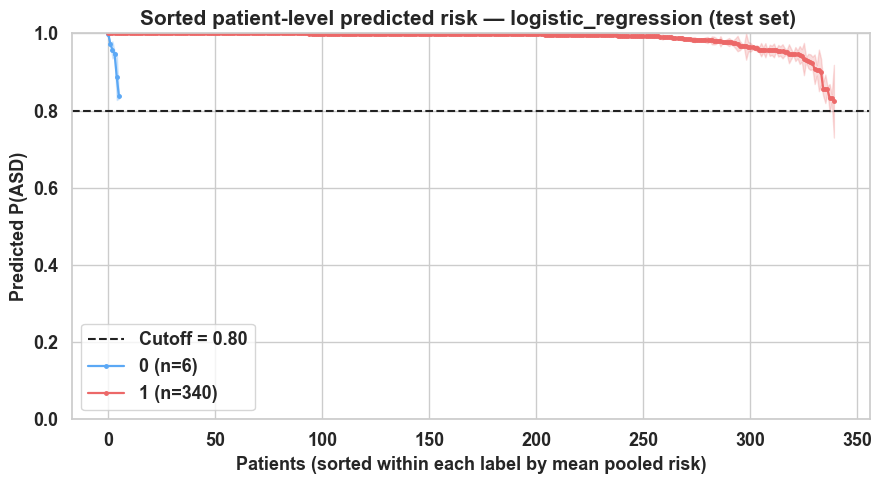

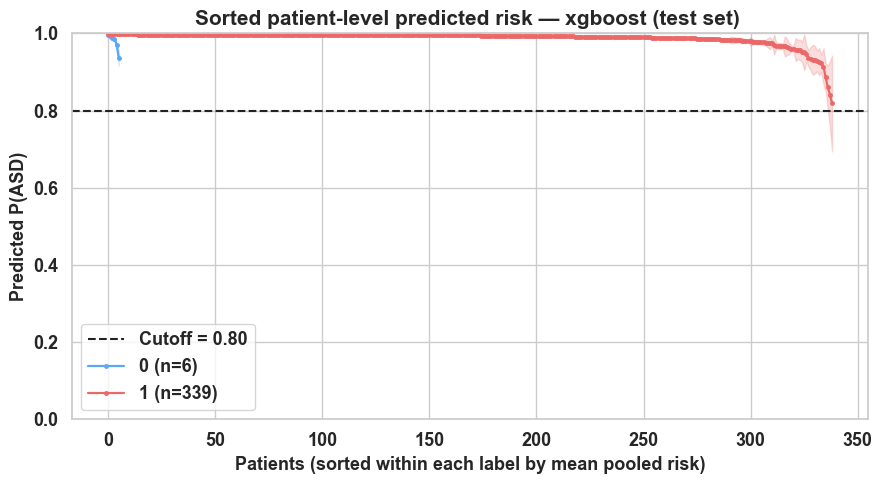

,model,variant,split,score_col,thr_low,thr_high,n_total,n_pos_total,n_neg_total,n_selected,...,fdr,fnr,baseline_prevalence,enrichment_factor,nns,confidence,precision,z_value,required_selected_n,implied_screened_n
0,logistic_regression,beta,test,p_mean,0.8,1.0,569,357,212,346,...,0.017341,0.047619,0.627417,1.566199,1.644509,0.95,0.05,1.959964,27,44
1,xgboost,beta,test,p_mean,0.8,1.0,569,357,212,345,...,0.017391,0.050420,0.627417,1.566119,1.649275,0.95,0.05,1.959964,27,44


In [5]:
_ = mtci.plot_ranked_patients_patient_level(
    df_hi_lr,
    model=None,
    variants=[ "beta"],
    colors=["#5BA8F5", "#EC6868"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)


_ = mtci.plot_ranked_patients_patient_level(
    df_hi_xgb,
    model=None,
    variants=[ "beta"],
    colors=["#5BA8F5", "#EC6868"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)



planning_table = pd.concat(
    [v["planning_summary"] for v in out.values()],
    axis=0,
    ignore_index=True,
)

display(planning_table)




In [6]:
# Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]
lr_top + ['y']

['worst texture',
 'worst concave points',
 'worst radius',
 'worst area',
 'area error',
 'worst concavity',
 'worst perimeter',
 'y']

# Chapter 2. Prospective enrichment workflow

This chapter demonstrates how the fixed enrichment rule is applied prospectively to patient-level data.

Given a set of screened patients, the ensemble model generates a patient-level predicted probability for each patient. The enrichment threshold is then applied to determine which patients are selected for the enriched cohort and which patients are not selected.

## 2.1 Example patient cohort
To illustrate how the enrichment rule is used in practice, we generate an example patient cohort based on balanced semi-synthetic sampling from the original dataset.

These example patients are used only to demonstrate the screening workflow and are not used to redefine the threshold.

In [7]:

# Features used for model development: Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]


feature_filters = {
    "logistic_regression": lr_top,
    "xgboost": xgb_top
}

model_data_dict = post.synthetic_data_validation(
    final_features=final_features,
    feature_filters=feature_filters,
    make_semisynthetic=True,
    semisynthetic_n_per_class=10,
    semisynthetic_noise_scale=0.05,  # 5% of each feature's SD
    semisynthetic_clip_to_observed_range=True,
    semisynthetic_random_state=42,
)


## 2.2 Ensemble scoring and enrichment decision
For each example patient, repeated model predictions are aggregated to obtain a patient-level ensemble probability.

Patients with predicted probability above the fixed threshold are selected for enrichment, while patients below the threshold are not selected.

In [8]:
# Synthetic data prep.
cols_lg = lr_top + ['y']
cols_xgb =   xgb_top + ['y']

test_data = {}
test_data['logistic_regression'] = model_data_dict['logistic_regression']['df_semisynthetic'][cols_lg]
test_data['xgboost']             = model_data_dict['xgboost']['df_semisynthetic'][cols_xgb]


# Generate external-set predictions for every fold model in `all_results` and store them back into each fold record using `*_external_*` keys (metrics only if labels exist).
#all_results    = mtci.load_all_results(output_dir='abcct_dataset_outputs/run_1/nonlinear_features', prefix='final_result', compress=True)
#all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)

all_results = vld.add_external_predictions_to_results(
    all_results,
    model_data_dict=test_data,
    y_col=None,   # or None if unlabeled, or just add the label column if present
    external_tag="external",
    feature_names_key="feature_names_used",
    strict_features=True,
)


# Build a single long-form  predictions table with one row per predicted example that is pooled across models. 
df_long = vld.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    include_uncalibrated=False,
)

# Aggregate repeated predictions per idx into a single row per (model, variant, idx), and optionally add an "ensemble" model by pooling predictions across multiple models.
df_agg = vld.aggregate_predictions_by_idx(
    df_long,
    calibrations=["uncalib", "beta"],
    add_ensemble=True,
    ensemble_name="Ensemble model",
    ensemble_models=None, #["logistic_regression", "xgboost"],  # optional; otherwise pools all selected
    truncate_decimals=4,
)

df_agg.head()

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used
0,Ensemble model,beta,0,NaN,30,0.0000,0.0000,0.0000,0.0000,0.0000,external,NaN,NaN
1,Ensemble model,beta,1,NaN,30,0.9958,0.9969,0.0042,0.9885,0.9999,external,NaN,NaN
2,Ensemble model,beta,2,NaN,30,0.9977,0.9983,0.0023,0.9924,0.9999,external,NaN,NaN
3,Ensemble model,beta,3,NaN,30,0.0000,0.0000,0.0000,0.0000,0.0000,external,NaN,NaN
4,Ensemble model,beta,4,NaN,30,0.0048,0.0018,0.0064,0.0000,0.0274,external,NaN,NaN


### Plot ranked screening predictions for enrichment decision-making.

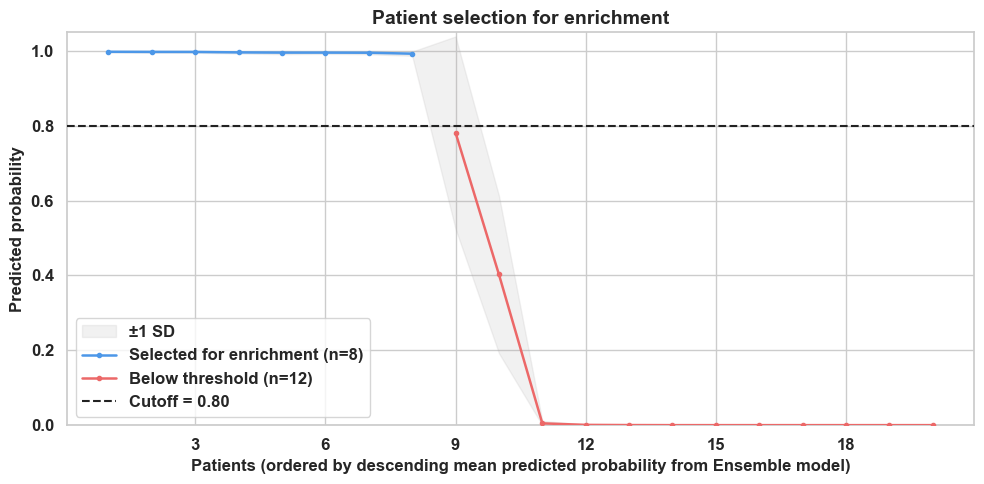

In [9]:

# In this example, we plot only the Ensemble model, so the function will:
#   1. order patients by the Ensemble model's p_mean values,
#   2. color patients above the cutoff as "selected for enrichment",
#   3. color patients at/below the cutoff as "below threshold",
#   4. show a neutral uncertainty ribbon using p_std.
ranked_dict = vld.plot_screening_predictions(
    df_pred=df_agg,                      # aggregated patient-level prediction table
    models=["Ensemble model"],           # models to plot; here we only show the Ensemble model
    # models=["logistic_regression", "xgboost", "Ensemble model"],  # example multi-model call

    reference_order_model="Ensemble model",  # model used to define the shared patient order on the x-axis
    calibration="beta",                 # use beta-calibrated probabilities
    center_col="p_mean",                # patient-level summary score used for ranking and thresholding
    std_col="p_std",                    # patient-level uncertainty column used for the ±1 SD ribbon

    figsize=(10, 5),                    # figure width and height
    cutoff=0.80,                        # fixed enrichment threshold: patients above this are considered selected
    ylim=(0, 1.05),                     # y-axis range; slight padding above 1.0 improves readability

    method_alias={                      # nicer display names used only in the plot labels
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
        "Ensemble model": "Ensemble model",
    },

    ribbon_color_single_model="#ADAAAA",  # neutral ribbon color for the single-model case
    title_prefix="Patient selection for enrichment",  # plot title
)


In [10]:
ranked_dict['Ensemble model'].head(3)

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used,patient_rank,selected_for_enrichment
0,Ensemble model,beta,15,NaN,30,0.9980,0.9983,0.0020,0.9926,0.9999,external,NaN,NaN,1,True
1,Ensemble model,beta,2,NaN,30,0.9977,0.9983,0.0023,0.9924,0.9999,external,NaN,NaN,2,True
2,Ensemble model,beta,17,NaN,30,0.9976,0.9980,0.0022,0.9924,0.9999,external,NaN,NaN,3,True


Together, these two chapters define the full ML-based enrichment workflow:

1. **Design and planning**  
   Use a fixed threshold to quantify enrichment performance and estimate the sample size needed for the next study.

2. **Prospective use**  
   Apply the ensemble model to patient-level data and use the fixed threshold to determine which patients are selected for enrichment.

This separates threshold justification from practical screening use while keeping both parts of the enrichment pipeline in one notebook.